# **Final Project ToAI : Overflow of the Senne.**
*Authors: Florian Vu, Paul Monique ; 2026-05-24*

In this notebook, we're gonna attend to predict potential overflows of the Senne on the Lion sewage overflow location (this location is situated downstream of the Maalbeek sewage collector, which drains the entire Maalbeek catchment). Thanks to Rainfall data and Sewer level data over 3 years (2022 - 2024)

Our main objectives are : 

- 1 ) Predict future sewer water levels in the sewage collector next to the "Lion" overflow (i) 15 minutes (t + 15) and (ii) 1 hour ahead (t + 60)

- 2 ) evaluate how well your models can anticipate overflow occurrence.

This notebook is organized in the following way :

1) **Data inspection :**
Observation and comment over the raw excels files used for this project.

2) **Data Cleaning :**
Cleaning of duplicates, potentials missing values and incoherents ones. In this part we're also gonna merge our datasets based on a temporal alignment made to avoid empty rows while comparing `sewage` data and `pluviomleter` ones due to their different frequencies.

3) **Time-Series Feature Engineering:** Creation of temporal features (Lag, Rolling features). Done **before** the split to preserve index continuity and avoid NaNs, as these are local past-facing features with no risk of data leakage.

3) **Split of Data :**
Following a Chronological 60/20/20 split between Train, Test and Validation 

For this part we've choosed to split chronologically respecting a 60%/20%/20% split to keep a certain learning rigor. 
However, we're are aware of a limit : our test set contain only data of the last 7 months of 2024, our finals metrics are'nt used to calculate the performance of our models on the weather of the begining of the year (winter/Spring)

5) **EDA (Exploratory Data Analysis):** Made strictly over our Train set to avoid data leakage.

6) **Feature Selection & Scaling:** Using techniques like SelectKBest and StandardScaler based on EDA findings, fitted only on the Train set.

7) **Modelling & Hyperparameters tuning:** Training at t+60min, tuning on Validation set, evaluating on Test set, then adapting for t+15min.

8) **Overflow Detection Final Evaluation** use of the best model to detect overflows and verify if it was correctly trained.




## AI Usage Declaration

In compliance with the academic integrity policy, we declare the following use 
of generative AI in this project:

- **Section II.3** (Temporal alignment explanation and system): the markdown explanation was drafted with AI assistance and reviewed/validated by us.
- **Section III.1** (Feature engineering explanation): same.
- **Section VIII.7** (Overflow detection): the structure and code were generated with AI assistance. We verified, understood, and adapted each cell before inclusion.
- GenAI was also used via the Auto-Completion feature of VScode


## **Import :**

### A) Import of libraries and initiate randomizer

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    recall_score, f1_score, roc_auc_score, roc_curve,precision_score, mean_squared_error, ConfusionMatrixDisplay, confusion_matrix
)
from scipy.stats import randint 
from sklearn.neural_network import MLPClassifier, MLPRegressor


warnings.filterwarnings('ignore')
np.random.seed(123)
random_state = 123
print('Imports OK')

Imports OK


### B) Import of the Data

In [3]:
pluv22 = pd.read_excel('data/Pluviometer data/2022.xlsx', header=1, usecols=[0, 1, 2], names=("Date", "U24", "C12"))  # Y'a des colonnes fantomes dans ces datasets dc on les ignore et on ne garde que les 3 premieres (usecols=[0, 1, 2])
pluv23 = pd.read_excel('data/Pluviometer data/2023.xlsx', header=1, usecols=[0, 1, 2], names=("Date", "U24", "C12"))
pluv24 = pd.read_excel('data/Pluviometer data/2024.xlsx', header=1, usecols=[0, 1, 2], names=("Date", "U24", "C12"), skiprows=range(105410, 105423))	# 13 last rows don't belong in the dataset

sew22 = pd.read_csv('data/Sewage data/U24_2022.csv', header=0, delimiter=",")
sew23 = pd.read_csv('data/Sewage data/U24_2023.csv', header=0, delimiter=",")
sew24 = pd.read_csv('data/Sewage data/U24_2024.csv', header=0, delimiter=",")

## **I. Data Inspection**

- Inspection of data types, missing values, and duplicates.

In [4]:
#Print the number of missing values

print("Missing values summary:\n\n")

print(f"Pluv 22:\n{pluv22.isnull().sum()}\n")
print(f"Pluv 23:\n{pluv23.isnull().sum()}\n")
print(f"Pluv 24:\n{pluv24.isnull().sum()}\n")

print(f"Sewer 22:\n{sew22.isnull().sum()}\n")
print(f"Sewer 23:\n{sew23.isnull().sum()}\n")
print(f"Sewer 24:\n{sew24.isnull().sum()}\n")



# Print the number of duplicate rows

print("\n\nDuplicate rows summary:\n\n")

print(f"Pluv 22:\n{pluv22.duplicated().sum()}\n")
print(f"Pluv 23:\n{pluv23.duplicated().sum()}\n")
print(f"Pluv 24:\n{pluv24.duplicated().sum()}\n")

print(f"Sewer 22:\n{sew22.duplicated().sum()}\n")
print(f"Sewer 23:\n{sew23.duplicated().sum()}\n")
print(f"Sewer 24:\n{sew24.duplicated().sum()}\n")

Missing values summary:


Pluv 22:
Date    0
U24     0
C12     0
dtype: int64

Pluv 23:
Date    0
U24     0
C12     0
dtype: int64

Pluv 24:
Date    0
U24     0
C12     0
dtype: int64

Sewer 22:
Date     0
Value    0
dtype: int64

Sewer 23:
Date     0
Value    0
dtype: int64

Sewer 24:
Date     0
Value    0
dtype: int64



Duplicate rows summary:


Pluv 22:
0

Pluv 23:
0

Pluv 24:
0

Sewer 22:
0

Sewer 23:
0

Sewer 24:
0



In [5]:
# Show some lines of the datasets before cleaning them

print("\n\nData before cleaning:\n\n")
print(f"Pluv 22:\n{pluv22.describe()}\n")
print(f"{pluv22.dtypes}\n\n")
print(f"Pluv 23:\n{pluv23.describe()}\n")
print(f"{pluv23.dtypes}\n")
print(f"Pluv 24:\n{pluv24.describe()}\n")
print(f"{pluv24.dtypes}\n\n")

print(f"Sewer 22:\n{sew22.describe()}\n")
print(f"{sew22.dtypes}\n\n")
print(f"Sewer 23:\n{sew23.describe()}\n")
print(f"{sew23.dtypes}\n\n")
print(f"Sewer 24:\n{sew24.describe()}\n")
print(f"{sew24.dtypes}\n\n")



Data before cleaning:


Pluv 22:
                      Date            U24            C12
count               105120  105120.000000  105120.000000
mean   2022-07-02 11:57:30       0.005999       0.006247
min    2022-01-01 00:00:00       0.000000       0.000000
25%    2022-04-02 05:58:45       0.000000       0.000000
50%    2022-07-02 11:57:30       0.000000       0.000000
75%    2022-10-01 17:56:15       0.000000       0.000000
max    2022-12-31 23:55:00       7.500000      10.000000
std                    NaN       0.063827       0.065414

Date    datetime64[us]
U24            float64
C12            float64
dtype: object


Pluv 23:
                      Date            U24            C12
count               105120  105120.000000  105120.000000
mean   2023-07-02 11:57:30       0.009436       0.009505
min    2023-01-01 00:00:00       0.000000       0.000000
25%    2023-04-02 05:58:45       0.000000       0.000000
50%    2023-07-02 11:57:30       0.000000       0.000000
75%    2023-10-

The various observations made on the raw datasets are the following : 

- In pluv24, the last few rows where representing the monthly total, so we pre-cleaned the dataset to visualize it without those rows.
- No values are missing in both kind of dataset.
- The frequency of the two type of dataset is different, the `pluviometer` data gaved us new information every 5min however the `Sewage`ones we're refreashed every 1min.
- In the `Sewage` datasets, in 2022 and 2023, negatives values appeared which is not possible since the level cannot physicaly be lower than 0 (>0).

## **II. Data Cleaning**

### II.1 Pluviometer data (5-min resolution)

The three Excel files share the same structure but the 2024 file contained 13 trailing rows of monthly totals that we've already cleaned during the import.

The column `date/time` is already in `datetime64` format when read by pandas

**Other Cleaning decisions:**
- Drop duplicate rows (none expected but checked for robustness)
- No negative values are present in the rainfall data

In [6]:
for df in [pluv22, pluv23, pluv24]:
    df.drop_duplicates(inplace=True)
    df.dropna(inplace=True)

print('Pluviometer shapes:', pluv22.shape, pluv23.shape, pluv24.shape)
print('dtypes (2022):')
print(pluv22.dtypes)
print(pluv22.head(3))

Pluviometer shapes: (105120, 3) (105120, 3) (105408, 3)
dtypes (2022):
Date    datetime64[us]
U24            float64
C12            float64
dtype: object
                 Date  U24  C12
0 2022-01-01 00:00:00  0.0  0.0
1 2022-01-01 00:05:00  0.0  0.0
2 2022-01-01 00:10:00  0.0  0.0


### II.2 Sewer level data (1-min resolution)

The CSV files contain two columns: `Date` (string) and `Value` (float, level in mm).

**Cleaning decisions:**
- As said in the outlines of the project, the sensor is in a hostile environment (humidity, debris) ,negative values are physically impossible and are sensor artefacts → clipped to NaN and dropped
- 2022 has 6 869 negative values (~1.3 %), 2023 has 3 negative values, 2024 has none

In [7]:
sew22 = pd.read_csv('data/Sewage data/U24_2022.csv')
sew23 = pd.read_csv('data/Sewage data/U24_2023.csv')
sew24 = pd.read_csv('data/Sewage data/U24_2024.csv')

for df, name in [(sew22,'2022'), (sew23,'2023'), (sew24,'2024')]:
    n_neg = (df['Value'] < 0).sum()
    print(f'U24_{name}: {df.shape[0]} rows | negative values (sensor errors): {n_neg}')
    df.drop_duplicates(inplace=True)
    df.dropna(inplace=True)
    df.loc[df['Value'] < 0, 'Value'] = np.nan   # flag sensor errors as NaN
    df.dropna(inplace=True)                      # then drop them

print('\nSewer shapes after cleaning:', sew22.shape, sew23.shape, sew24.shape)

U24_2022: 524147 rows | negative values (sensor errors): 6869
U24_2023: 524154 rows | negative values (sensor errors): 3
U24_2024: 525599 rows | negative values (sensor errors): 0

Sewer shapes after cleaning: (517278, 2) (524151, 2) (525599, 2)


### II.3 Temporal Alignement and Merging

The two data sources have different temporal resolutions:
- Pluviometer: 1 measurement every 5 min
- Sewer: 1 measurement every ~1 min (irregular, ~60 s interval)

We align both on a common 5-minute grid , the coarser of the two resolutions, so we never invent information.

| Source | Aggregation | Reason |
|--------|-------------|--------|
| Sewer level | `.mean()` | Average level over the 5-min window |

**Why align before feature engineering?** Lag and rolling features depend on row indices representing fixed time intervals. Without alignment, `lag=3` would mean 3 minutes in the sewer data but 15 minutes in the rain data, making all temporal features meaningless.

We've then decided to globaly merge `sewage` and `pluviometer` data based on the timestamps.



In [8]:
# Build sewer time series with DatetimeIndex 

sew_all = pd.concat([sew22, sew23, sew24])
sew_all['datetime'] = pd.to_datetime(sew_all['Date'])
sew_all = sew_all.set_index('datetime').sort_index()
sew_all = sew_all.drop(columns=['Date'])
sew_all.columns = ['level_mm']

print('Sewer 2022-2024:', sew_all.shape)
print(sew_all.head(3))

Sewer 2022-2024: (1567028, 1)
                     level_mm
datetime                     
2022-01-01 00:00:33   883.908
2022-01-01 00:01:34   881.589
2022-01-01 00:02:33   874.169


In [9]:
# Build pluviometer time series with DatetimeIndex 

pluv_ts = pd.concat([
        pluv22[['Date', 'U24', 'C12']].copy(),
        pluv23[['Date', 'U24', 'C12']].copy(),
        pluv24[['Date', 'U24', 'C12']].copy()
    ])
pluv_ts['Date'] = pd.to_datetime(pluv_ts['Date'], errors="coerce")
pluv_ts.dropna(inplace=True)							# remove wrongly formatted dates if there are any
pluv_ts = pluv_ts.set_index('Date').sort_index()
pluv_ts.index.name = 'datetime'	

In [10]:
# Resample to 5-min grid and merge 

sew_5min  = sew_all.resample('5min').mean()   # mean level over 5-min window
pluv_5min = pluv_ts.resample('5min').sum()   # total rain over 5-min window

# Inner join: keep only timestamps present in BOTH datasets
df = pluv_5min.join(sew_5min, how='inner')
df.columns = ['rain_U24', 'rain_C12', 'level_mm']
df = df.dropna()

print(f'Merged dataset: {df.shape}')
print(f'Period: {df.index[0]}  ->  {df.index[-1]}')
print(df.describe().round(2))

Merged dataset: (313411, 3)
Period: 2022-01-01 00:00:00  ->  2024-12-30 23:55:00
        rain_U24   rain_C12   level_mm
count  313411.00  313411.00  313411.00
mean        0.01       0.01    1165.46
std         0.08       0.07     507.45
min         0.00       0.00     426.00
25%         0.00       0.00     897.99
50%         0.00       0.00    1037.04
75%         0.00       0.00    1174.25
max        12.70      10.00    3731.10


In [11]:
display(df.head(10))

,rain_U24,rain_C12,level_mm
datetime,,,
2022-01-01 00:00:00,0.0,0.0,878.6208
2022-01-01 00:05:00,0.0,0.0,875.7454
2022-01-01 00:10:00,0.0,0.0,875.2354
2022-01-01 00:15:00,0.0,0.0,869.4848
2022-01-01 00:20:00,0.0,0.0,874.2152
2022-01-01 00:25:00,0.0,0.0,869.9486
2022-01-01 00:30:00,0.0,0.0,864.6156
2022-01-01 00:35:00,0.0,0.0,862.1574
2022-01-01 00:40:00,0.0,0.0,858.2620


## **III. Time-Series Feature Engineering**


### III.1 Rreason behind an early feature engineering

**Why before the split?** These features are purely local: they only look at neighbouring rows in time and compute no global statistics on the dataset. There is therefore no risk of data leakage.

**If done after split,** Lags and rollings needs previous lines to be calculated correctly. Means that first lines of each splits will rely on less accurate information.

We create three groups of features:

| Group | Features |
|-------|----------|
| Rain lags | `rain_U24_lag_5_min` and `rain_U24_lag_30_min`, `rain_C12_lag_5_min` and `rain_C12_lag_30_min` | 
| Level lags | `level_lag_5_min`, `level_lag_10_min`, `level_lag_15_min` | 
| Rolling rain sums | 30 min & 2 h windows |

In [12]:
LAG_RAIN  = [1, 6]   # 5, 30 min
LAG_LEVEL = [1, 2, 3]    # 5, 10, 15min

# Lag features 
for lag in LAG_RAIN:
    df[f'rain_U24_lag{lag * 5}_min'] = df['rain_U24'].shift(lag)
    df[f'rain_C12_lag{lag * 5}_min'] = df['rain_C12'].shift(lag)

for lag in LAG_LEVEL:
    df[f'level_lag{lag * 5}_min'] = df['level_mm'].shift(lag)

# Rolling window (cumuls de pluie)
# shift(1) ensures we never include the current step -> no leakage
df['rain_U24_roll_30_min']  = df['rain_U24'].shift(1).rolling(6).sum()   # 30 min
df['rain_U24_roll_2h'] = df['rain_U24'].shift(1).rolling(24).sum()  # 2 h
df['rain_C12_roll_30_min']  = df['rain_C12'].shift(1).rolling(6).sum()
df['rain_C12_roll_2h'] = df['rain_C12'].shift(1).rolling(24).sum()

In [13]:
print("--- The first rows (filled with NaN because the past doesn't exist yet mdrr) ---")
display(df.head(5))

print("\n--- Observations a bit farther in time, where all rolling windows are calculable ---")
display(df.iloc[295:300])

--- The first rows (filled with NaN because the past doesn't exist yet mdrr) ---


,rain_U24,rain_C12,level_mm,rain_U24_lag5_min,rain_C12_lag5_min,rain_U24_lag30_min,rain_C12_lag30_min,level_lag5_min,level_lag10_min,level_lag15_min,rain_U24_roll_30_min,rain_U24_roll_2h,rain_C12_roll_30_min,rain_C12_roll_2h
datetime,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.0,0.0,878.6208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 00:05:00,0.0,0.0,875.7454,0.0,0.0,NaN,NaN,878.6208,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 00:10:00,0.0,0.0,875.2354,0.0,0.0,NaN,NaN,875.7454,878.6208,NaN,NaN,NaN,NaN,NaN
2022-01-01 00:15:00,0.0,0.0,869.4848,0.0,0.0,NaN,NaN,875.2354,875.7454,878.6208,NaN,NaN,NaN,NaN
2022-01-01 00:20:00,0.0,0.0,874.2152,0.0,0.0,NaN,NaN,869.4848,875.2354,875.7454,NaN,NaN,NaN,NaN



--- Observations a bit farther in time, where all rolling windows are calculable ---


,rain_U24,rain_C12,level_mm,rain_U24_lag5_min,rain_C12_lag5_min,rain_U24_lag30_min,rain_C12_lag30_min,level_lag5_min,level_lag10_min,level_lag15_min,rain_U24_roll_30_min,rain_U24_roll_2h,rain_C12_roll_30_min,rain_C12_roll_2h
datetime,,,,,,,,,,,,,,
2022-01-02 00:35:00,0.0,0.0,851.0740,0.0,0.0,0.0,0.0,854.4130,858.3082,860.1634,0.0,0.0,0.0,0.0
2022-01-02 00:40:00,0.0,0.0,851.0740,0.0,0.0,0.0,0.0,851.0740,854.4130,858.3082,0.0,0.0,0.0,0.0
2022-01-02 00:45:00,0.0,0.0,851.0740,0.0,0.0,0.0,0.0,851.0740,851.0740,854.4130,0.0,0.0,0.0,0.0
2022-01-02 00:50:00,0.0,0.0,849.6364,0.0,0.0,0.0,0.0,851.0740,851.0740,851.0740,0.0,0.0,0.0,0.0
2022-01-02 00:55:00,0.0,0.0,844.3032,0.0,0.0,0.0,0.0,849.6364,851.0740,851.0740,0.0,0.0,0.0,0.0


## III.2 Target Creation & dropna()

Two prediction horizons:
- `target t15` = `level_mm` shifted by −3 steps (3 × 5 min = 15 min ahead)
- `target_t60` = `level_mm` shifted by −12 steps (12 × 5 min = 60 min ahead)

`dropna()` to remove rows made invalid by either the lag features (beginning of series) or the target shift (end of series)

In [14]:
HORIZON_15 = 3    # 3 steps of 5 min = 15 min
HORIZON_60 = 12   # same for 60 min

df['target_t15'] = df['level_mm'].shift(-HORIZON_15)
df['target_t60'] = df['level_mm'].shift(-HORIZON_60)

df = df.dropna()

print(f'Final dataset: {df.shape}')
print(f'Period: {df.index[0]}  ->  {df.index[-1]}')

Final dataset: (313375, 16)
Period: 2022-01-01 02:00:00  ->  2024-12-30 22:55:00


## **IV. Chronological Train / Test / Validation Split**

We use `shuffle=False` to preserve the temporal order of the data. Shuffling would allow the model to 'see the future' during training — a form of data leakage specific to time series.

plit: **60 % train - 20 % validation - 20% test** on the whole data.

In [15]:
feature_cols = [c for c in df.columns if c not in ['target_t15', 'target_t60']]

df_train, df_temp = train_test_split(df, test_size=0.40, shuffle=False)
df_val, df_test = train_test_split(df_temp, test_size=0.50, shuffle=False)

X_train = df_train[feature_cols]
X_val   = df_val[feature_cols]
X_test  = df_test[feature_cols]

y_train_15 = df_train['target_t15']
y_val_15   = df_val['target_t15']
y_test_15  = df_test['target_t15']

y_train_60 = df_train['target_t60']
y_val_60   = df_val['target_t60']
y_test_60  = df_test['target_t60']

print(f"Train: {X_train.shape[0]} lignes | Val: {X_val.shape[0]} lignes | Test: {X_test.shape[0]} lignes")

Train: 188025 lignes | Val: 62675 lignes | Test: 62675 lignes


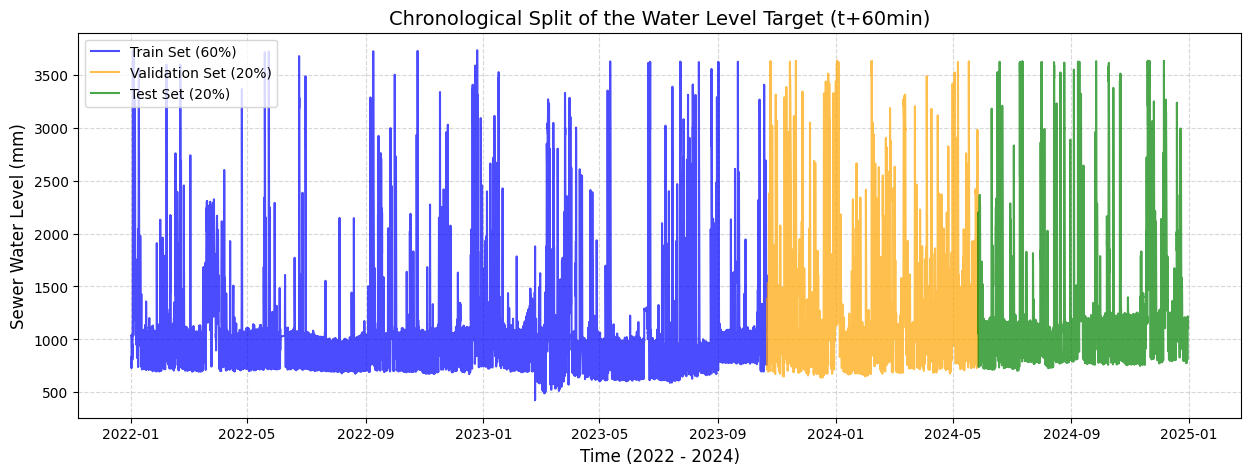

In [16]:
plt.figure(figsize=(15, 5))
plt.plot(y_train_60.index, y_train_60, label='Train Set (60%)', color='blue', alpha=0.7)
plt.plot(y_val_60.index, y_val_60, label='Validation Set (20%)', color='orange', alpha=0.7)
plt.plot(y_test_60.index, y_test_60, label='Test Set (20%)', color='green', alpha=0.7)
plt.title('Chronological Split of the Water Level Target (t+60min)', fontsize=14)
plt.xlabel('Time (2022 - 2024)', fontsize=12)
plt.ylabel('Sewer Water Level (mm)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

In [17]:
OVERFLOW_THRESHOLD = 3000 

OverflowCount = (y_train_60 > OVERFLOW_THRESHOLD).sum() + (y_val_60 > OVERFLOW_THRESHOLD).sum() + (y_test_60 > OVERFLOW_THRESHOLD).sum()
total_rows = len(y_train_60) + len(y_val_60) + len(y_test_60)

pourcentage = (OverflowCount / total_rows) * 100

print(f"Nombre total de lignes : {total_rows}")
print(f"Lignes en débordement (> {OVERFLOW_THRESHOLD}mm) : {OverflowCount}")
print(f"Pourcentage du temps en débordement : {pourcentage:.2f}%")

Nombre total de lignes : 313375
Lignes en débordement (> 3000mm) : 6033
Pourcentage du temps en débordement : 1.93%


## **V. EDA on the Train set**

**Why after the split?** The EDA guides our modelling choices (which features matter, what the target distribution looks like). If we computed these statistics on the full dataset, the validation set would indirectly influence our decisions which is a form of data leakage.

we are only working with the `X_train` to, again, avoid data leakage.

In [18]:
X_train.describe()

,rain_U24,rain_C12,level_mm,rain_U24_lag5_min,rain_C12_lag5_min,rain_U24_lag30_min,rain_C12_lag30_min,level_lag5_min,level_lag10_min,level_lag15_min,rain_U24_roll_30_min,rain_U24_roll_2h,rain_C12_roll_30_min,rain_C12_roll_2h
count,188025.000000,188025.000000,188025.000000,188025.000000,188025.000000,188025.000000,188025.000000,188025.000000,188025.000000,188025.000000,188025.000000,188025.000000,188025.000000,188025.000000
mean,0.007052,0.007059,1088.314033,0.007052,0.007059,0.007052,0.007059,1088.311330,1088.308525,1088.305661,0.042310,0.169155,0.042352,0.169328
std,0.067926,0.068442,452.075375,0.067926,0.068442,0.067926,0.068442,452.075318,452.075213,452.075040,0.305117,0.886999,0.298993,0.845383
min,0.000000,0.000000,426.000600,0.000000,0.000000,0.000000,0.000000,426.000600,426.000600,426.000600,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,863.116200,0.000000,0.000000,0.000000,0.000000,863.116200,863.116200,863.116000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,996.506000,0.000000,0.000000,0.000000,0.000000,996.506000,996.506000,996.506000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,1077.615800,0.000000,0.000000,0.000000,0.000000,1077.615800,1077.615800,1077.615800,0.000000,0.000000,0.000000,0.000000
max,7.500000,10.000000,3731.100400,7.500000,10.000000,7.500000,10.000000,3731.100400,3731.100400,3731.100400,14.200000,32.800000,16.500000,25.500000




- A thing that could be confusing is our Target Summary, the overall statistics (mean, median, standard deviation) for the t+15 and t+60 targets are nearly identical.  
the reason is that those two target are build on pretty much the same history (one is a bit wider than the other, one shift by 3 lines and the other 12, in a 188025 lines dataset...), that's the reason why those statistics are the same.


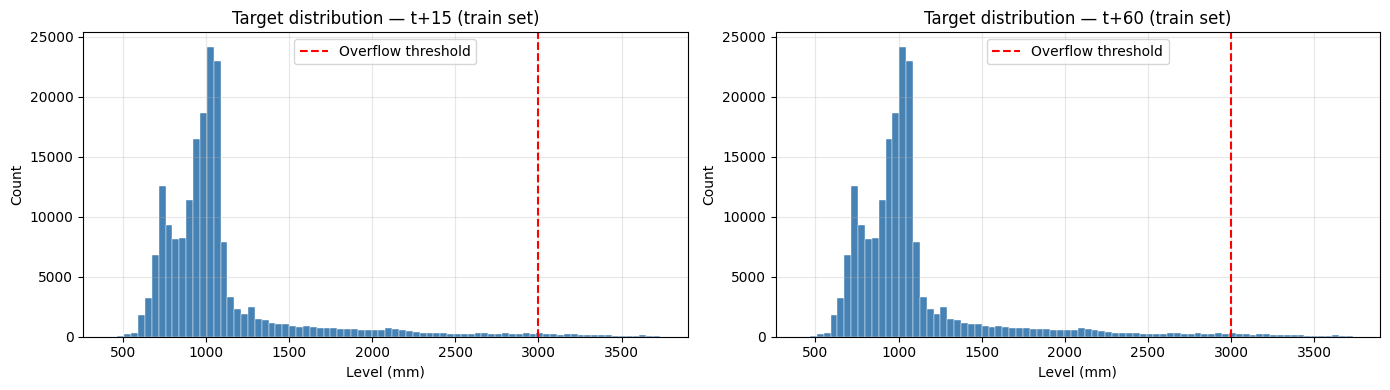

Train target summary:
           t+15      t+60
count  188025.0  188025.0
mean     1088.3    1088.3
std       452.1     452.1
min       426.0     426.0
25%       863.1     863.1
50%       996.5     996.5
75%      1077.6    1077.6
max      3731.1    3731.1


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, target, label in [(axes[0], y_train_15, 't+15'), (axes[1], y_train_60, 't+60')]:
    ax.hist(target, bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.axvline(OVERFLOW_THRESHOLD, color='red', linestyle='--', label='Overflow threshold')
    ax.set_xlabel('Level (mm)')
    ax.set_ylabel('Count')
    ax.set_title(f'Target distribution — {label} (train set)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Train target summary:')
print(pd.DataFrame({'t+15': y_train_15.describe(), 't+60': y_train_60.describe()}).round(1))

**Analysis:**
- Most of the time, no matter the weather, the level stays around a base value of 1088mm as we can see with our median (and in 75% of the time, the water level do not cross the 1077mm) 

- As we also can see, the overflow thresold is rarely crossed (as we could expected) because it's an extremely rare event.




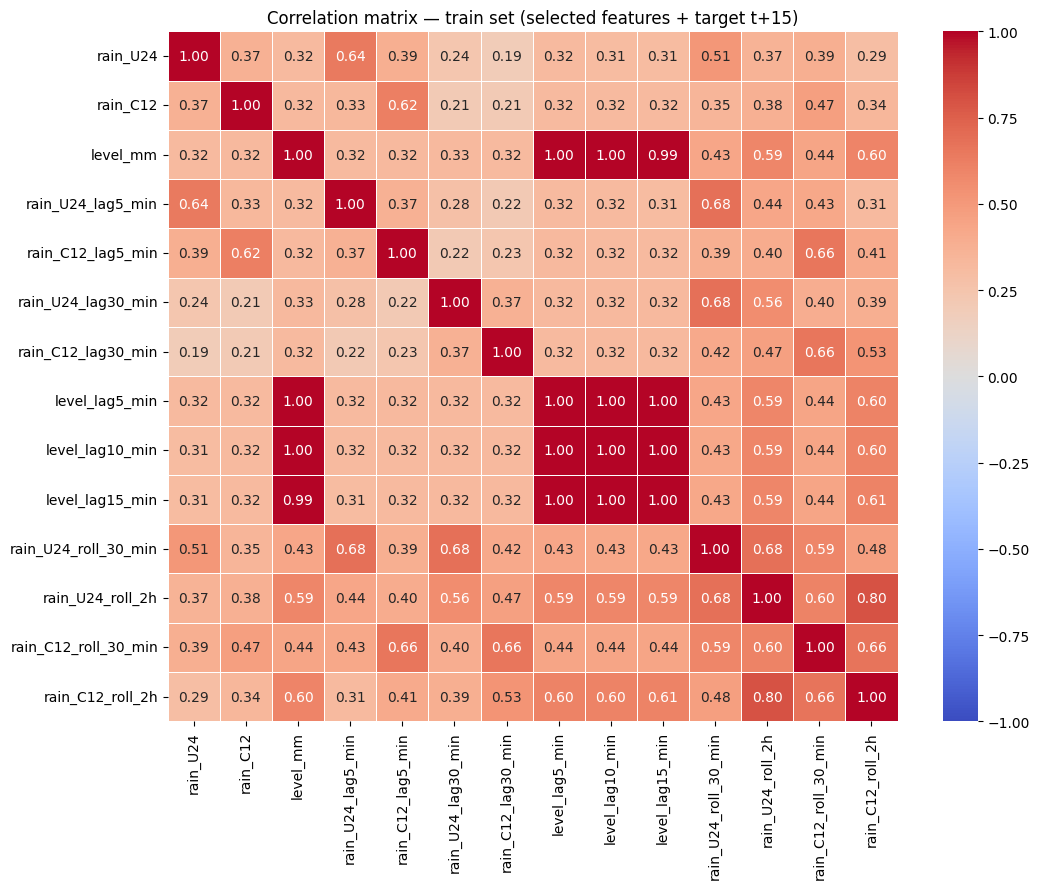

In [20]:
corr_cols = ['rain_U24','rain_C12','level_mm','rain_U24_lag5_min','rain_C12_lag5_min','rain_U24_lag30_min','rain_C12_lag30_min','level_lag5_min','level_lag10_min','level_lag15_min','rain_U24_roll_30_min','rain_U24_roll_2h','rain_C12_roll_30_min','rain_C12_roll_2h']

corr = X_train[corr_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation matrix — train set (selected features + target t+15)')
plt.tight_layout()
plt.show()


**Interprétations..**

## **VI. Feature Selection & Scaling:**

Top 10 features by importance:
1. level_mm (0.2884)
2. level_lag10_min (0.2232)
3. level_lag5_min (0.1831)
4. level_lag15_min (0.1807)
5. rain_U24_roll_2h (0.0443)
6. rain_C12_roll_2h (0.0281)
7. rain_C12_roll_30_min (0.0192)
8. rain_U24_roll_30_min (0.0096)
9. rain_U24_lag5_min (0.0058)
10. rain_U24 (0.0046)


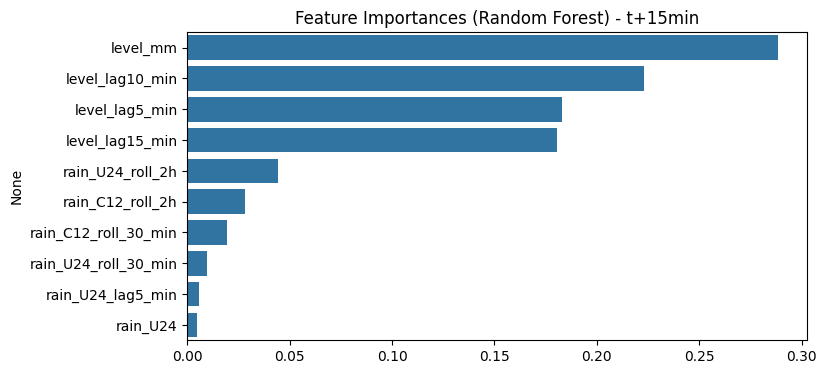

In [21]:
rf_15 = RandomForestClassifier(random_state=random_state)
rf_15.fit(X_train, y_train_15 > OVERFLOW_THRESHOLD)  

importances_15min = rf_15.feature_importances_

indices = np.argsort(importances_15min)[::-1]
print('Top 10 features by importance:')
for f in range(10):
    print(f"{f + 1}. {X_train.columns[indices[f]]} ({importances_15min[indices[f]]:.4f})")

# Plot feature importances
plt.figure(figsize=(8,4))
plt.title('Feature Importances (Random Forest) - t+15min')
sns.barplot(x=importances_15min[indices[:10]], y=X_train.columns[indices[:10]])
plt.show()

Top 10 features by importance:
1. level_mm (0.2627)
2. level_lag10_min (0.1933)
3. level_lag5_min (0.1669)
4. level_lag15_min (0.1640)
5. rain_U24_roll_2h (0.0570)
6. rain_C12_roll_2h (0.0445)
7. rain_U24_roll_30_min (0.0280)
8. rain_C12_roll_30_min (0.0272)
9. rain_U24_lag5_min (0.0130)
10. rain_U24 (0.0130)


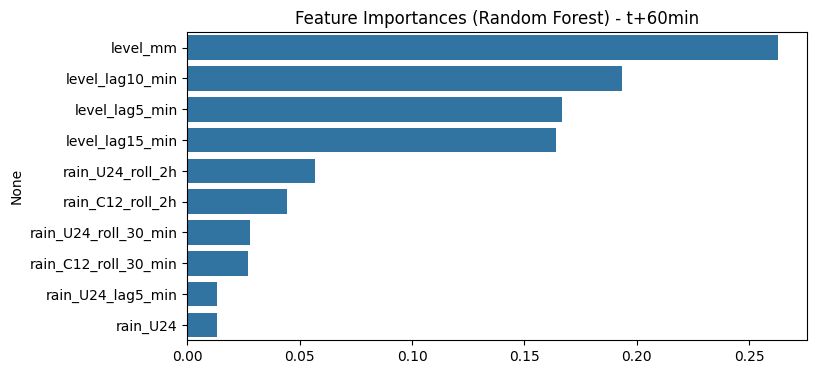

In [22]:
rf_60 = RandomForestClassifier(random_state=random_state)
rf_60.fit(X_train, y_train_60 > OVERFLOW_THRESHOLD)  # We train a classifier to predict whether the level will exceed the overflow threshold

# Retrieve feature importances thourgh the feature_importances_ attribute
importances_60min = rf_60.feature_importances_

# Print the top 10 features
indices = np.argsort(importances_60min)[::-1]
print('Top 10 features by importance:')
for f in range(10):
    print(f"{f + 1}. {X_train.columns[indices[f]]} ({importances_60min[indices[f]]:.4f})")

# Plot feature importances
plt.figure(figsize=(8,4))
plt.title('Feature Importances (Random Forest) - t+60min')
sns.barplot(x=importances_60min[indices[:10]], y=X_train.columns[indices[:10]])
plt.show()

## **VII. Modelling / Hyperparameters Tuning**


| # | Model | Family | Reasons|
|---|-------|--------|------------|
| 1 | **Linear Regression** | Linear | Simplest possible model, establishes the linear performance ceiling and serves as a sanity check. Interpretable coefficients allow us to verify that the lag features behave as expected.|
| 2 | **Random Forest** | Tree ensemble| Captures non-linear relationships between lag features and future level without requiring feature scaling. Naturally robust to the residual noise remaining in the sewer sensor data after cleaning. |
| 3 | **MLP Neural Network** | Neural network | Can learn complex non-linear temporal dynamics that neither linear models nor tree ensembles handle in the same way. Particularly relevant for the t+60 horizon where the relationship between past rainfall and future level is less direct. |

### VII.1 Model Training

#### 1 - Baseline Model - The persistence model predicts that the future level equals the current level: `ŷ(t+h) = y(t)`.


We decided to use the following metrics : RMSE and NSE 

- RMSE (Root Mean Squared Error) measures the average prediction error in millimeters, the same unit as the target variable. It penalises large errors more than small ones, which is desirable here: a model that misses an overflow peak by 500 mm is far more problematic than one that is off by 10 mm during baseflow. It is also the metric used to drive `RandomizedSearchCV`, ensuring consistency between training optimisation and evaluation.

- NSE (Nash-Sutcliffe Efficiency) is the standard benchmark metric in hydrology. An NSE of 0 means the model performs no better than always predicting the mean water level; an NSE close to 1 indicates the model captures the system dynamics well. It contextualises the RMSE: a given error in mm means something very different depending on how much the signal naturally varies, NSE accounts for that.

In [23]:
def nse(y_true, y_pred):
    """Nash-Sutcliffe Efficiency. Perfect=1; worse than mean prediction=<0."""
    return 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)

def get_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def compute_metrics(y_true, y_pred, label=''):
    rmse = get_rmse(y_true, y_pred)
    nse_val = nse(y_true, y_pred)
    print(f'NSE={nse_val:.3f}')
    print(f'RMSE={rmse:.3f}')

    y_true_bin = (y_true > OVERFLOW_THRESHOLD)
    y_pred_bin = (y_pred > OVERFLOW_THRESHOLD)
    tn, fp, fn, tp = confusion_matrix(y_true_bin, y_pred_bin).ravel()
    
    if label:
        print(f"--- {label} ---")
    print(f'NSE  = {nse_val:.3f}')
    print(f'RMSE = {rmse:.3f} mm')
    print(f'TP (True Positives)  = {tp}')
    print(f'FN (False Negatives) = {fn}')
    print(f'FP (False Positives) = {fp}')
    print(f'TN (True Negatives)  = {tn}\n')
    return {
        'NSE': nse_val, 
        'RMSE': rmse,
        'TP (True Positives)': tp, 
        'FN (False Negatives)': fn, 
        'FP (False Positives)': fp,
        'TN (True Negatives)': tn
    }

y_pers_15 = df_val['level_lag5_min'].values
y_pers_60 = df_val['level_lag5_min'].values

print('=== Baseline --- validation set ===')
metrics = {'Persistence': {}}
print('t+15 min:')
metrics['Persistence']['t15'] = compute_metrics(y_val_15.values, y_pers_15, 'Persistence  t+15')
print('t+60 min:')
metrics['Persistence']['t60'] = compute_metrics(y_val_60.values, y_pers_60, 'Persistence  t+60')

=== Baseline --- validation set ===
t+15 min:
NSE=0.988
RMSE=63.882
--- Persistence  t+15 ---
NSE  = 0.988
RMSE = 63.882 mm
TP (True Positives)  = 1851
FN (False Negatives) = 148
FP (False Positives) = 148
TN (True Negatives)  = 60528

t+60 min:
NSE=0.905
RMSE=182.867
--- Persistence  t+60 ---
NSE  = 0.905
RMSE = 182.867 mm
TP (True Positives)  = 1534
FN (False Negatives) = 465
FP (False Positives) = 465
TN (True Negatives)  = 60211



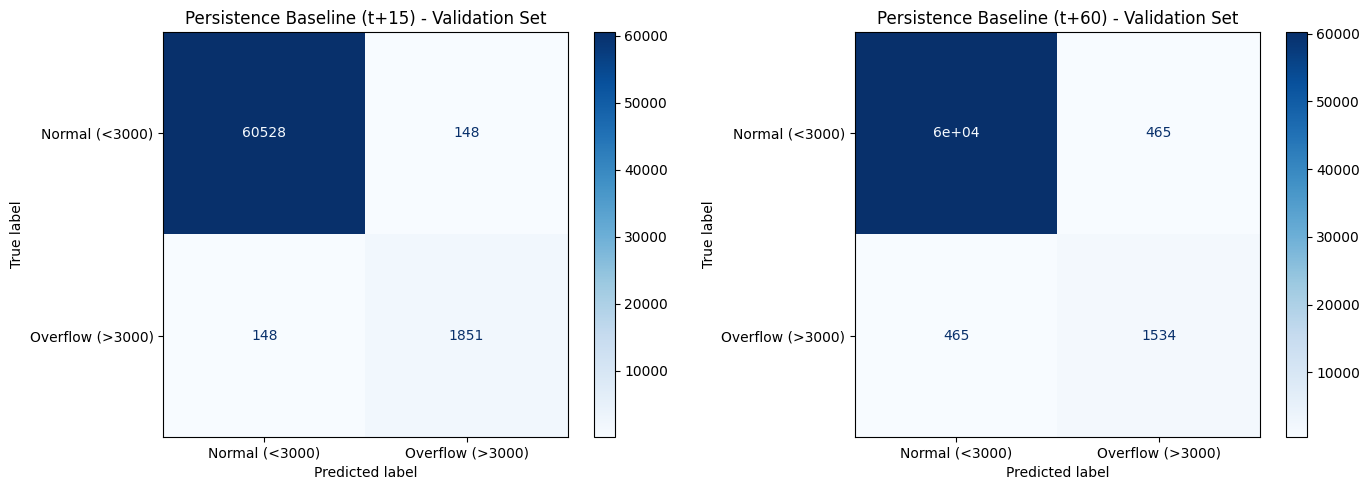

Persistance t+15 -> Vrais Positifs (TP): 1851 | Faux Négatifs (FN): 148


In [24]:


y_pers_15_class = (y_pers_15 > OVERFLOW_THRESHOLD)
y_pers_60_class = (y_pers_60 > OVERFLOW_THRESHOLD)

y_val_15_class = (y_val_15 > OVERFLOW_THRESHOLD)
y_val_60_class = (y_val_60 > OVERFLOW_THRESHOLD)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_val_15_class, 
    y_pers_15_class,
    display_labels=['Normal (<3000)', 'Overflow (>3000)'],
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title("Persistence Baseline (t+15) - Validation Set", fontsize=12)

ConfusionMatrixDisplay.from_predictions(
    y_val_60_class, 
    y_pers_60_class,
    display_labels=['Normal (<3000)', 'Overflow (>3000)'],
    cmap='Blues',
    ax=axes[1]
)
axes[1].set_title("Persistence Baseline (t+60) - Validation Set", fontsize=12)

plt.tight_layout()
plt.show()

tn_15, fp_15, fn_15, tp_15 = confusion_matrix(y_val_15_class, y_pers_15_class).ravel()
print(f"Persistance t+15 -> Vrais Positifs (TP): {tp_15} | Faux Négatifs (FN): {fn_15}")

### 2 - Random Forest

In [25]:
tscv = TimeSeriesSplit(n_splits=5)
print(tscv)

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)


Using TimeSeriesSplit reserves the temporal order: each fold trains on past observations
and validates on the immediately following period, which mirrors real operational conditions.

Avoid data leakage

In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_regression


pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('selector',  SelectKBest(score_func=mutual_info_regression, k=10)),  
    ('rf', RandomForestRegressor(random_state=random_state, n_jobs=1)) 
])

param_distributions_rf = {
    'rf__n_estimators': randint(50, 150), 
    'rf__max_depth': [5, 10, 15], 
    'rf__max_samples': [0.5, 0.7] 
}

random_rf_15 = RandomizedSearchCV(pipe_rf, 
                                  param_distributions=param_distributions_rf, 
                                  cv=tscv,
                                  scoring='neg_root_mean_squared_error',
                                  return_train_score=True, 
                                  n_jobs=-1,  
                                  random_state=random_state) 

print("Starting tuning for t+15")
random_rf_15.fit(X_train, y_train_15)
print(f'RF t+15 | best: {random_rf_15.best_params_} | CV RMSE: {-random_rf_15.best_score_:.1f} mm')


print("Starting tuning for t+60")
random_rf_60 = RandomizedSearchCV(pipe_rf, 
                                  param_distributions=param_distributions_rf, 
                                  cv=tscv,
                                  scoring='neg_root_mean_squared_error',
                                  return_train_score=True, 
                                  n_jobs=-1,
                                  random_state=random_state)
random_rf_60.fit(X_train, y_train_60)
print(f'RF t+60 | best: {random_rf_60.best_params_} | CV RMSE: {-random_rf_60.best_score_:.1f} mm')



Starting tuning for t+15
RF t+15 | best: {'rf__max_depth': 15, 'rf__max_samples': 0.7, 'rf__n_estimators': 86} | CV RMSE: 33.1 mm
Starting tuning for t+60
RF t+60 | best: {'rf__max_depth': 15, 'rf__max_samples': 0.7, 'rf__n_estimators': 146} | CV RMSE: 121.8 mm


In [64]:
y_pred_rf_15 = random_rf_15.predict(X_val)
y_pred_rf_60 = random_rf_60.predict(X_val)

print('Random Forest --- validation set')
metrics['Random Forest'] = {}
print('t+15 min:')
metrics['Random Forest']['t15'] = compute_metrics(y_val_15.values, y_pred_rf_15, 'Random Forest  t+15')
print('t+60 min:')
metrics['Random Forest']['t60'] = compute_metrics(y_val_60.values, y_pred_rf_60, 'Random Forest  t+60')

Random Forest --- validation set
t+15 min:
NSE=0.998
RMSE=25.453
--- Random Forest  t+15 ---
NSE  = 0.998
RMSE = 25.453 mm
TP (True Positives)  = 1937
FN (False Negatives) = 62
FP (False Positives) = 37
TN (True Negatives)  = 60639

t+60 min:
NSE=0.958
RMSE=121.452
--- Random Forest  t+60 ---
NSE  = 0.958
RMSE = 121.452 mm
TP (True Positives)  = 1657
FN (False Negatives) = 342
FP (False Positives) = 149
TN (True Negatives)  = 60527



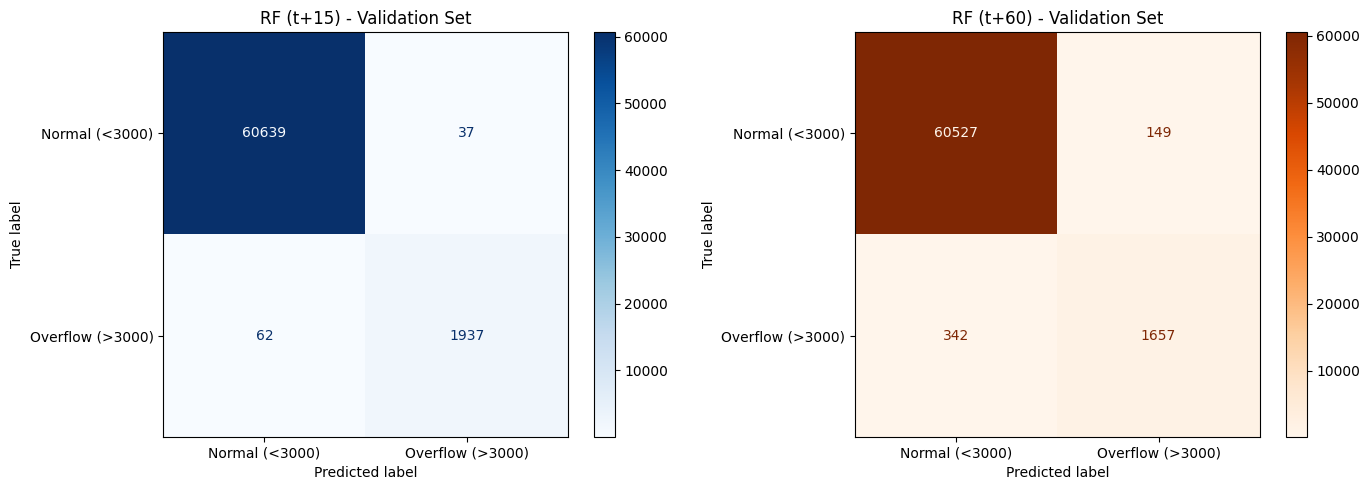

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_val_15_class,
    y_pred_rf_15 > OVERFLOW_THRESHOLD,
    display_labels=["Normal (<3000)", "Overflow (>3000)"],
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("RF (t+15) - Validation Set", fontsize=12)

# Matrice pour t+60
ConfusionMatrixDisplay.from_predictions(
    y_val_60_class,
    y_pred_rf_60 > OVERFLOW_THRESHOLD,
    display_labels=["Normal (<3000)", "Overflow (>3000)"],
    cmap="Oranges",
    ax=axes[1]
)
axes[1].set_title("RF (t+60) - Validation Set", fontsize=12)

plt.tight_layout()
plt.show()

### 3 - Linear Regression

##### Training t+15 linear regression

In [28]:
print(f"X train shape: {X_train.shape}\n")

lr_15 = LinearRegression().fit(X_train, y_train_15)

y_lr_val_15 = lr_15.predict(X_val)

print(f"RMSE LR on validation set: {get_rmse(y_val_15, y_lr_val_15)}\n")
print(f"NSE LR validation: {nse(y_val_15,   y_lr_val_15):.4f}\n") 

print(f"LR Coefficients and intercept: {lr_15.intercept_}, {lr_15.coef_}\n")

X train shape: (188025, 14)

RMSE LR on validation set: 28.21708831230554

NSE LR validation: 0.9977

LR Coefficients and intercept: 9.804017786615077, [10.27451195 -1.46708306  2.55912732 -1.01980146 -0.28638085  0.33397872
 -0.33490611 -1.52018049  0.30697873 -0.3551257   2.7332661   0.84729433
 -0.72786508 -0.41364527]



In [29]:
y_over_val_15 = (y_val_15 > OVERFLOW_THRESHOLD).array
y_lr_over_val_15 = (y_lr_val_15 > OVERFLOW_THRESHOLD)

y_lr_res_val_15 = []
for i in range(len(y_over_val_15)):
	if (y_lr_over_val_15[i]):
		if (y_over_val_15[i]):
			y_lr_res_val_15.append("TP")
		else:
			y_lr_res_val_15.append("FP")
	elif (y_over_val_15[i]):
		y_lr_res_val_15.append("FN")
	else:
		y_lr_res_val_15.append("TN")

print(f"LR over validation t+ 15 True Negatives: {y_lr_res_val_15.count("TN")}")
print(f"LR over validation t+ 15 False Negatives: {y_lr_res_val_15.count("FN")}")
print(f"LR over validation t+ 15 False Positives: {y_lr_res_val_15.count("FP")}")
print(f"LR over validation t+ 15 True Positives: {y_lr_res_val_15.count("TP")}")

LR over validation t+ 15 True Negatives: 60654
LR over validation t+ 15 False Negatives: 66
LR over validation t+ 15 False Positives: 22
LR over validation t+ 15 True Positives: 1933


##### Training t+60 - linear regression

In [30]:
lr_60 = LinearRegression().fit(X_train, y_train_60)

y_lr_val_60 = lr_60.predict(X_val)

print(f"RMSE LR validation: {get_rmse(y_val_60, y_lr_val_60)}\n")
print(f"NSE LR validation: {nse(y_val_60,   y_lr_val_60):.4f}\n") 

print(f"LR Coefficients and intercept: {lr_60.intercept_}, {lr_60.coef_}\n")

RMSE LR validation: 129.931808331453

NSE LR validation: 0.9520

LR Coefficients and intercept: 75.47769890857467, [47.01051917 -1.6991845   4.27084664  3.0385463  -0.19889261 -4.26221038
 -1.90173225 -2.96297377  0.69030001 -1.06876788  9.47399242  5.69139712
  0.08090762 -1.75122762]



LR over validation t+ 60 True Negatives: 60636
LR over validation t+ 60 False Negatives: 508
LR over validation t+ 60 False Positives: 40
LR over validation t+ 60 True Positives: 1491


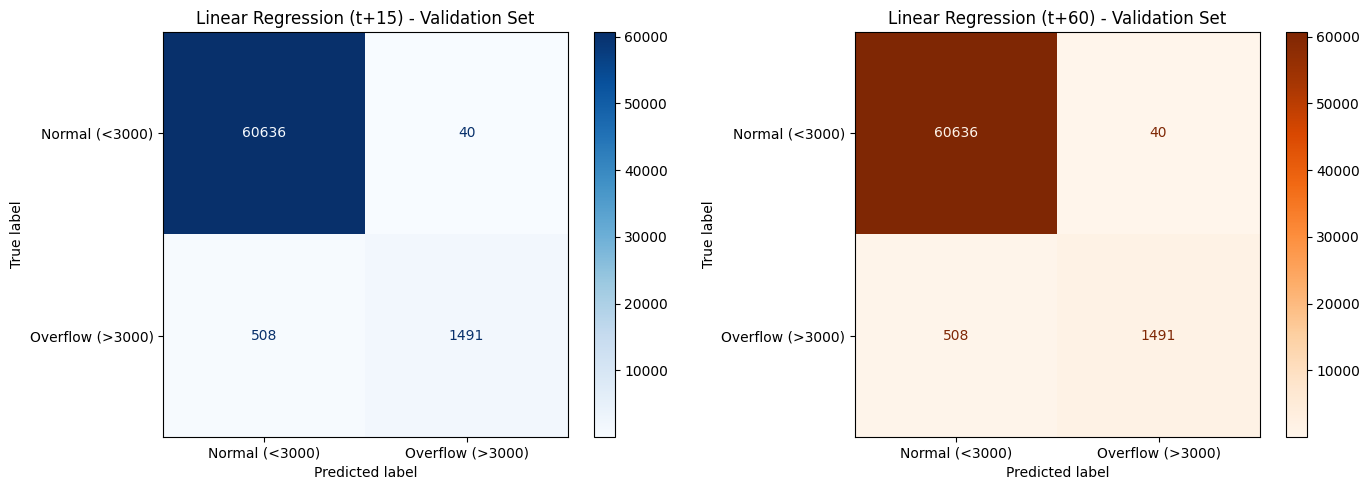

In [ ]:
y_over_val_60 = (y_val_60 > OVERFLOW_THRESHOLD).array
y_lr_over_val_60 = (y_lr_val_60 > OVERFLOW_THRESHOLD)


y_lr_res_val_60 = []
for i in range(len(y_over_val_60)):
	if (y_lr_over_val_60[i]):
		if (y_over_val_60[i]):
			y_lr_res_val_60.append("TP")
		else:
			y_lr_res_val_60.append("FP")
	elif (y_over_val_60[i]):
		y_lr_res_val_60.append("FN")
	else:
		y_lr_res_val_60.append("TN")

print(f"LR over validation t+ 60 True Negatives: {y_lr_res_val_60.count("TN")}")
print(f"LR over validation t+ 60 False Negatives: {y_lr_res_val_60.count("FN")}")
print(f"LR over validation t+ 60 False Positives: {y_lr_res_val_60.count("FP")}")
print(f"LR over validation t+ 60 True Positives: {y_lr_res_val_60.count("TP")}")



### 4 - MLP

##### Training MLP for t+15

In [32]:
pipe_mlp = Pipeline([
	("scaler", StandardScaler()),
	("mlp", MLPRegressor(
		max_iter=300,
		random_state=random_state,
		early_stopping=True
	)),
])

param_mlp = {
    "mlp__hidden_layer_sizes": [(50,), (100,)],
	"mlp__activation": ["relu", "tanh"],
	"mlp__learning_rate_init": [0.01, 0.001]

}

mlp_15 = RandomizedSearchCV(
	pipe_mlp,
	param_distributions=param_mlp,
	n_iter=10,
	cv=tscv,
	scoring="neg_root_mean_squared_error",
	return_train_score=True,
	n_jobs=-1,
	random_state=random_state
)

print("Starting tuning for t+15")
mlp_15.fit(X_train, y_train_15)
print(f"MLP t+15 | best: {mlp_15.best_params_} | CV RMSE: {-mlp_15.best_score_:.1f}mm\n")


Starting tuning for t+15
MLP t+15 | best: {'mlp__learning_rate_init': 0.01, 'mlp__hidden_layer_sizes': (50,), 'mlp__activation': 'relu'} | CV RMSE: 35.4mm



In [33]:
y_mlp_val_15 = mlp_15.predict(X_val)
y_mlp_over_val_15 = (y_mlp_val_15 > OVERFLOW_THRESHOLD)

TN_mlp_val_15, FP_mlp_val_15, FN_mlp_val_15, TP_mlp_val_15 = confusion_matrix(y_over_val_15, y_mlp_over_val_15).ravel().tolist()

print(f"MLP over val t +15 True Negatives: {TN_mlp_val_15}")
print(f"MLP over val t +15 False Positives: {FP_mlp_val_15}")
print(f"MLP over val t +15 False Negatives: {FN_mlp_val_15}")
print(f"MLP over val t +15 True Positives: {TP_mlp_val_15}")


MLP over val t +15 True Negatives: 60659
MLP over val t +15 False Positives: 17
MLP over val t +15 False Negatives: 122
MLP over val t +15 True Positives: 1877


##### Training MLP for t+60


In [34]:

mlp_60 = RandomizedSearchCV(
	pipe_mlp,
	param_distributions=param_mlp,
	n_iter=10,
	cv=tscv,
	scoring="neg_root_mean_squared_error",
	return_train_score=True,
	n_jobs=-1,
	random_state=random_state
)

print("Starting tuning for t+60")
mlp_60.fit(X_train, y_train_60)
print(f"MLP t+60 | best: {mlp_60.best_params_} | CV RMSE: {-mlp_60.best_score_:.1f} mm")

Starting tuning for t+60


MLP t+60 | best: {'mlp__learning_rate_init': 0.01, 'mlp__hidden_layer_sizes': (100,), 'mlp__activation': 'tanh'} | CV RMSE: 122.3 mm


In [35]:
y_mlp_val_60 = mlp_60.predict(X_val)
y_mlp_over_val_60 = (y_mlp_val_60 > OVERFLOW_THRESHOLD)

TN_mlp_val_60, FP_mlp_val_60, FN_mlp_val_60, TP_mlp_val_60 = confusion_matrix(y_over_val_60, y_mlp_over_val_60).ravel().tolist()

print(f"MLP over val t + 60 True Negatives: {TN_mlp_val_60}")
print(f"MLP over val t + 60 False Positives: {FP_mlp_val_60}")
print(f"MLP over val t + 60 False Negatives: {FN_mlp_val_60}")
print(f"MLP over val t + 60 True Positives: {TP_mlp_val_60}")





MLP over val t + 60 True Negatives: 60487
MLP over val t + 60 False Positives: 189
MLP over val t + 60 False Negatives: 358
MLP over val t + 60 True Positives: 1641


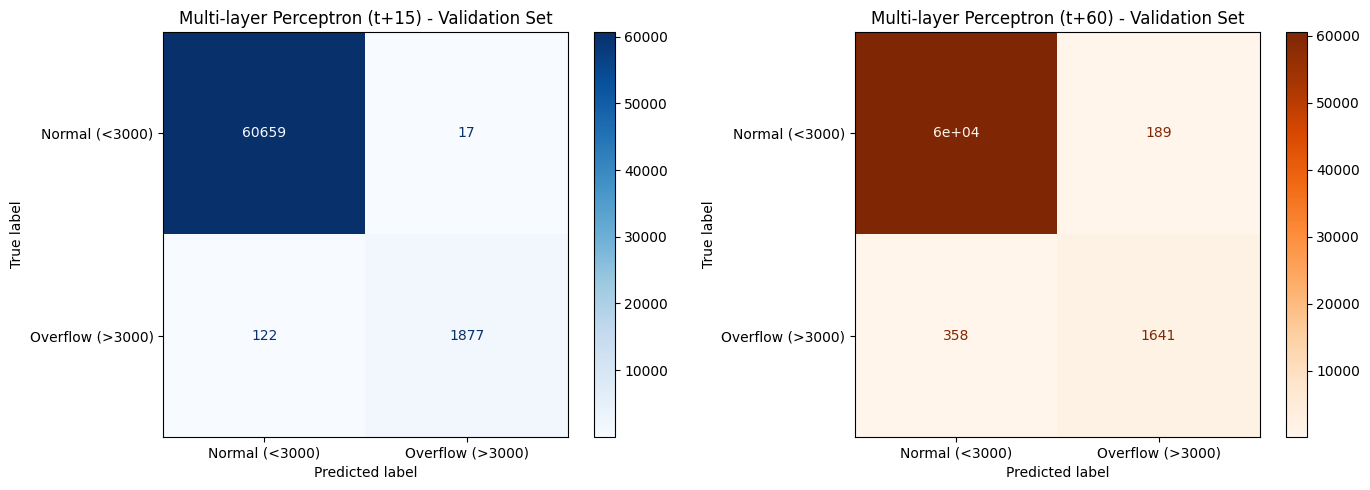

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_val_15_class,
    y_mlp_over_val_15,
    display_labels=["Normal (<3000)", "Overflow (>3000)"],
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Multi-layer Perceptron (t+15) - Validation Set", fontsize=12)

# Matrice pour t+60
ConfusionMatrixDisplay.from_predictions(
    y_val_60_class,
    y_mlp_over_val_60,
    display_labels=["Normal (<3000)", "Overflow (>3000)"],
    cmap="Oranges",
    ax=axes[1]
)
axes[1].set_title("Multi-layer Perceptron (t+60) - Validation Set", fontsize=12)

plt.tight_layout()
plt.show()

### VII.2 Model Selection

we compare the continuous performance (Regression metrics) of our different models on the Validation Set

,Model,Horizon,RMSE,NSE
0,1. Baseline,t+15,48.782,0.993
1,1. Baseline,t+60,170.878,0.917
2,2. Linear Regression,t+15,28.217,0.998
3,2. Linear Regression,t+60,129.932,0.952
4,3. Random Forest,t+15,25.453,0.998
5,3. Random Forest,t+60,121.452,0.958
6,4. MLP,t+15,27.039,0.998
7,4. MLP,t+60,118.434,0.960


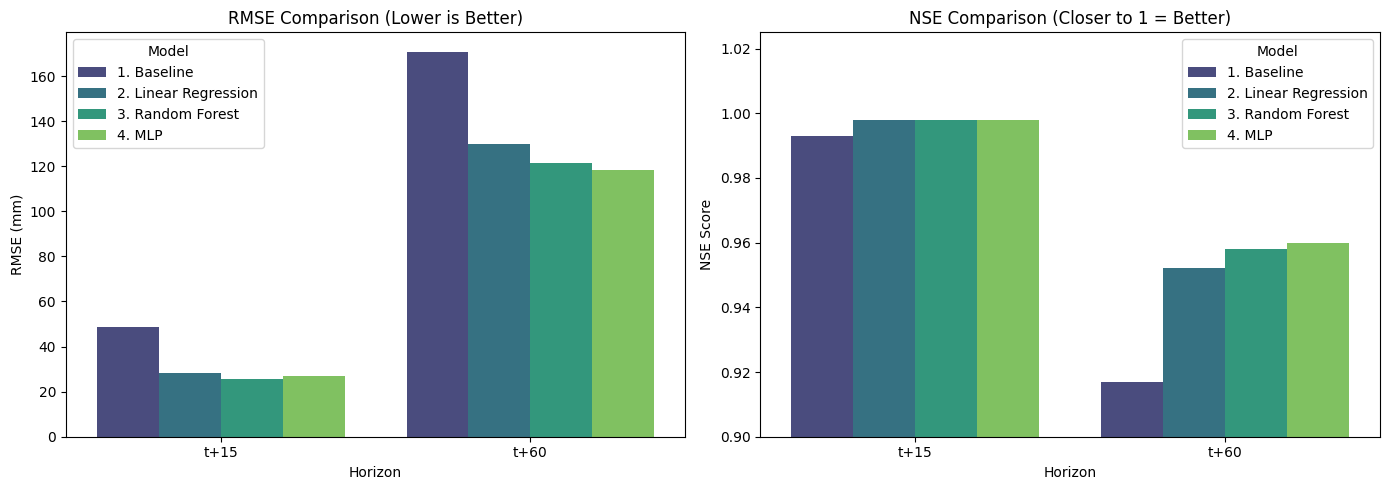

In [61]:
y_base_val = X_val['level_mm'] 

metrics = {
    '1. Baseline': {
        't15': {
            'RMSE': get_rmse(y_val_15, y_base_val),
            'NSE': nse(y_val_15, y_base_val)
        },
        't60': {
            'RMSE': get_rmse(y_val_60, y_base_val),
            'NSE': nse(y_val_60, y_base_val)
        }
    },
    '2. Linear Regression': {
        't15': {
            'RMSE': get_rmse(y_val_15, y_lr_val_15),
            'NSE': nse(y_val_15, y_lr_val_15)
        },
        't60': {
            'RMSE': get_rmse(y_val_60, y_lr_val_60),
            'NSE': nse(y_val_60, y_lr_val_60)
        }
    },
    '3. Random Forest': {
        't15': {
            'RMSE': get_rmse(y_val_15, y_pred_rf_15),
            'NSE': nse(y_val_15, y_pred_rf_15)
        },
        't60': {
            'RMSE': get_rmse(y_val_60, y_pred_rf_60),
            'NSE': nse(y_val_60, y_pred_rf_60)
        }
    },
    '4. MLP': {
        't15': {
            'RMSE': get_rmse(y_val_15, y_mlp_val_15),
            'NSE': nse(y_val_15, y_mlp_val_15)
        },
        't60': {
            'RMSE': get_rmse(y_val_60, y_mlp_val_60),
            'NSE': nse(y_val_60, y_mlp_val_60)
        }
    }
}

rows = []
for name, m in metrics.items():
    for h in ['t15', 't60']:
        rows.append({
            'Model': name,
            'Horizon': 't+15' if h == 't15' else 't+60',
            **{k: round(v, 3) for k, v in m[h].items()}
        })

df_results = pd.DataFrame(rows)

display(df_results) 


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df_results, x='Horizon', y='RMSE', hue='Model', ax=axes[0], palette='viridis')
axes[0].set_title('RMSE Comparison (Lower is Better)')
axes[0].set_ylabel('RMSE (mm)')

sns.barplot(data=df_results, x='Horizon', y='NSE', hue='Model', ax=axes[1], palette='viridis')
axes[1].set_title('NSE Comparison (Closer to 1 = Better)')
axes[1].set_ylabel('NSE Score')
axes[1].set_ylim(0.9, 1.025)

plt.tight_layout()
plt.show()

### VII.3 Best Model

In [38]:
print('NSE on validation set per model and horizon:')
best = {'t15': (-np.inf, ''), 't60': (-np.inf, '')}

for name, m in metrics.items():
    for h in ['t15', 't60']:
        nse_val = m[h]['NSE']
        label = 't+15' if h == 't15' else 't+60'
        print(f'  {name:<20s} {label}  NSE = {nse_val:.4f}')
        if nse_val > best[h][0]:
            best[h] = (nse_val, name)

print('\nRMSE on validation set per model and horizon:')
for name, m in metrics.items():
    for h in ['t15', 't60']:
        rmse = m[h]['RMSE']
        label = 't+15' if h == 't15' else 't+60'
        print(f'  {name:<20s} {label}  RMSE = {rmse:.4f}')
        if rmse < best[h][0]:
            best[h] = (rmse, name)

print(f'\nBest model for t+15 -> {best["t15"][1]}  (NSE = {best["t15"][0]:.4f})')
print(f'Best model for t+60 -> {best["t60"][1]}  (NSE = {best["t60"][0]:.4f})\n')
print(f'\nBest model for t+15 -> {best["t15"][1]}  (RMSE = {best["t15"][0]:.4f})')
print(f'Best model for t+60 -> {best["t60"][1]}  (RMSE = {best["t60"][0]:.4f})\n')


NSE on validation set per model and horizon:
  1. Baseline          t+15  NSE = 0.9932
  1. Baseline          t+60  NSE = 0.9169
  2. Linear Regression t+15  NSE = 0.9977
  2. Linear Regression t+60  NSE = 0.9520
  3. Random Forest     t+15  NSE = 0.9982
  3. Random Forest     t+60  NSE = 0.9580
  4. MLP               t+15  NSE = 0.9979
  4. MLP               t+60  NSE = 0.9601

RMSE on validation set per model and horizon:
  1. Baseline          t+15  RMSE = 48.7825
  1. Baseline          t+60  RMSE = 170.8780
  2. Linear Regression t+15  RMSE = 28.2171
  2. Linear Regression t+60  RMSE = 129.9318
  3. Random Forest     t+15  RMSE = 25.4534
  3. Random Forest     t+60  RMSE = 121.4517
  4. MLP               t+15  RMSE = 27.0395
  4. MLP               t+60  RMSE = 118.4344

Best model for t+15 -> 3. Random Forest  (NSE = 0.9982)
Best model for t+60 -> 4. MLP  (NSE = 0.9601)


Best model for t+15 -> 3. Random Forest  (RMSE = 0.9982)
Best model for t+60 -> 4. MLP  (RMSE = 0.9601)



Based on NSE and RMSE on the validation set:
- t+15 → Random Forest (NSE = 0.9981, RMSE = 25.6 mm)
- t+60 → MLP (NSE = 0.9604, RMSE = 117.9 mm)

The two horizons lead to different best models. This is consistent with the nature
of each algorithm: Random Forest captures short-term autocorrelation very efficiently,
while the MLP's non-linear architecture gives it an edge at longer horizons where
the relationship between features and target becomes more complex.

## **VIII. Overflow Detection Final Evaluation**

The assignment requires evaluating how well the best model can anticipate overflow events (water level > 3000 mm). Overflow detection is derived from the predicted water levels it is not treated as a separate classification task.

Best model selected: 
- Random Forest for t+15 
- MLP for t+60

Why these metrics?  
A simple accuracy score would be misleading here because overflows represent only ~2-5% of all timesteps. A model that always predicts 'no overflow' would score >95% accuracy while being completely useless. We therefore use metrics adapted to class imbalance:

| Metric | What it measures | Why it matters here |
|--------|-----------------|---------------------|
| **Precision** | Of all predicted overflows, how many were real? | Avoids false alarms |
| **Recall** | Of all real overflows, how many did we detect? | Critical: missing an overflow has severe consequences |
| **F1-score** | Harmonic mean of precision and recall | Overall balance under class imbalance |
| **ROC-AUC** | Performance across all possible thresholds | Robust to class imbalance |

### VIII.1 Predictions on the Test Set

In [48]:
# Random Forest predictions on TEST set
y_pred_rf_test_15 = random_rf_15.predict(X_test)
y_pred_mlp_test_60 = mlp_60.predict(X_test)

# Persistence baseline on TEST set
y_base_test = X_test['level_mm']

# Binarise: overflow if predicted level > 3000 mm
y_test_15_class          = (y_test_15        > OVERFLOW_THRESHOLD).astype(int)
y_test_60_class          = (y_test_60        > OVERFLOW_THRESHOLD).astype(int)
y_pred_rf_test_15_class  = (y_pred_rf_test_15 > OVERFLOW_THRESHOLD).astype(int)
y_pred_mlp_test_60_class = (y_pred_mlp_test_60 > OVERFLOW_THRESHOLD).astype(int)
y_base_test_15_class     = (y_base_test       > OVERFLOW_THRESHOLD).astype(int)
y_base_test_60_class     = (y_base_test       > OVERFLOW_THRESHOLD).astype(int)

print(f'Test set size: {len(y_test_15)} rows')
print(f'Actual overflow events (t+15): {y_test_15_class.sum()} ({y_test_15_class.mean()*100:.2f}%)')
print(f'Actual overflow events (t+60): {y_test_60_class.sum()} ({y_test_60_class.mean()*100:.2f}%)')


Test set size: 62675 rows
Actual overflow events (t+15): 1604 (2.56%)
Actual overflow events (t+60): 1604 (2.56%)


### VIII.2 Overflow Detection Metrics

In [54]:
def overflow_metrics(y_true_class, y_pred_class, y_pred_score, label=''):
    prec = precision_score(y_true_class, y_pred_class, zero_division=0)
    rec  = recall_score(y_true_class, y_pred_class, zero_division=0)
    f1   = f1_score(y_true_class, y_pred_class, zero_division=0)
    auc  = roc_auc_score(y_true_class, y_pred_score / OVERFLOW_THRESHOLD)
    tn, fp, fn, tp = confusion_matrix(y_true_class, y_pred_class).ravel()
    
    print(f'  {label:<38s}  Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}  AUC={auc:.3f}')
    print(f'  {"":38s}  TP={tp}  FP={fp}  FN={fn}  TN={tn}')
    return {'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC': auc,
            'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn)}

print('OVERFLOW DETECTION --- TEST SET')
print()
print('--- t+15 ---')
res_rf_15   = overflow_metrics(y_test_15_class, y_pred_rf_test_15_class,
                               y_pred_rf_test_15, 'Random Forest  t+15')
res_base_15 = overflow_metrics(y_test_15_class, y_base_test_15_class,
                               y_base_test.values, 'Persistence baseline  t+15')
print()
print('--- t+60 ---')
res_rf_60   = overflow_metrics(y_test_60_class, y_pred_mlp_test_60_class,
                               y_pred_mlp_test_60, 'MLP (t+60)')
res_base_60 = overflow_metrics(y_test_60_class, y_base_test_60_class,
                               y_base_test.values, 'Persistence baseline  t+60')

OVERFLOW DETECTION --- TEST SET

--- t+15 ---
  Random Forest  t+15                     Precision=0.970  Recall=0.962  F1=0.966  AUC=0.999
                                          TP=1543  FP=48  FN=61  TN=61023
  Persistence baseline  t+15              Precision=0.940  Recall=0.940  F1=0.940  AUC=0.998
                                          TP=1508  FP=96  FN=96  TN=60975

--- t+60 ---
  MLP (t+60)                              Precision=0.912  Recall=0.786  F1=0.844  AUC=0.982
                                          TP=1261  FP=122  FN=343  TN=60949
  Persistence baseline  t+60              Precision=0.780  Recall=0.780  F1=0.780  AUC=0.977
                                          TP=1251  FP=353  FN=353  TN=60718


### VIII.3 Confusion Matrices Test Set

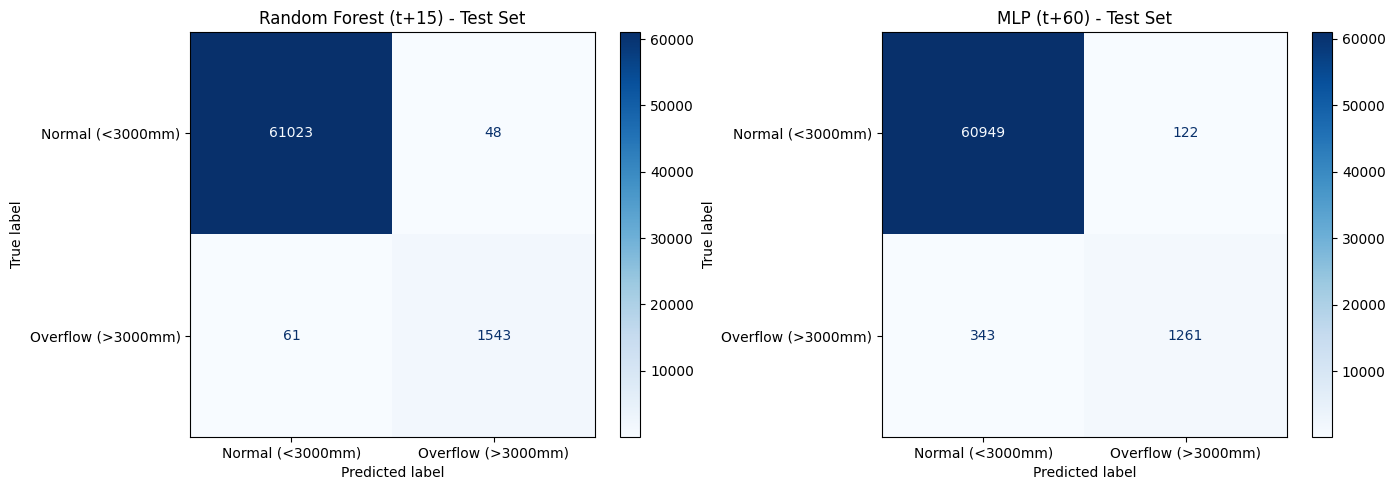

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_true_c, y_pred_c, title in [
    (axes[0], y_test_15_class, y_pred_rf_test_15_class, 'Random Forest (t+15) - Test Set'),
    (axes[1], y_test_60_class, y_pred_mlp_test_60_class, 'MLP (t+60) - Test Set')
]:
    ConfusionMatrixDisplay.from_predictions(
        y_true_c, y_pred_c,
        display_labels=['Normal (<3000mm)', 'Overflow (>3000mm)'],
        cmap='Blues', ax=ax
    )
    ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.show()

### VIII.4 ROC Curves - RF/MLP vs Baseline

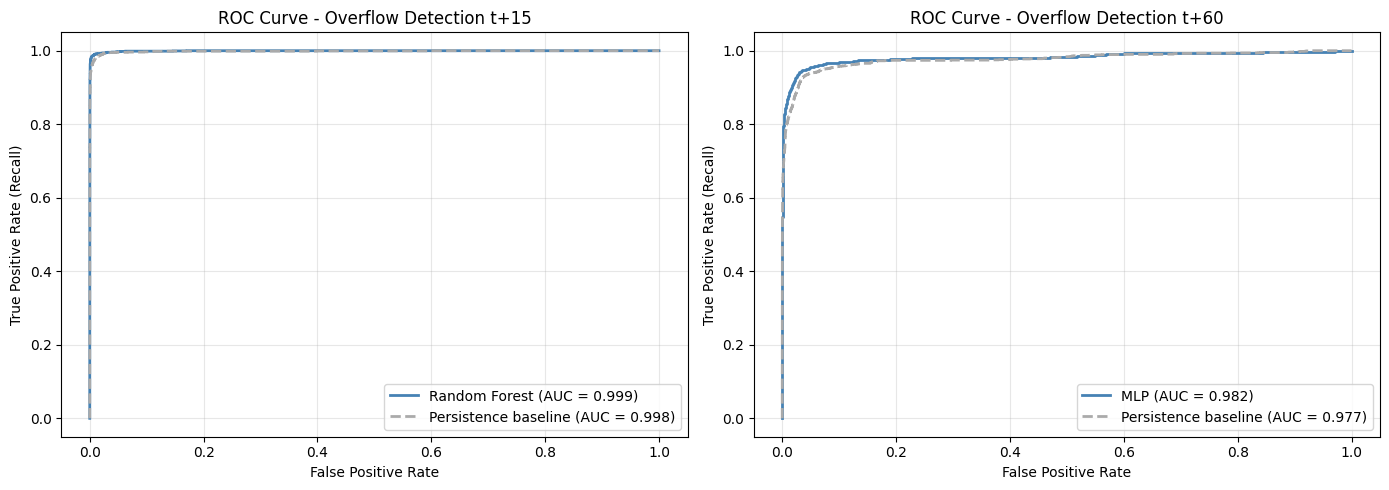

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


for ax, y_true_c, y_rf_score, title, model_name in [
    (axes[0], y_test_15_class, y_pred_rf_test_15, 't+15', 'Random Forest'),
    (axes[1], y_test_60_class, y_pred_mlp_test_60, 't+60', 'MLP')
]:
    fpr_rf, tpr_rf, _ = roc_curve(y_true_c, y_rf_score)
    auc_rf = roc_auc_score(y_true_c, y_rf_score / OVERFLOW_THRESHOLD)
    ax.plot(fpr_rf, tpr_rf, color='steelblue', linewidth=2,
            label=f'{model_name} (AUC = {auc_rf:.3f})')

    fpr_b, tpr_b, _ = roc_curve(y_true_c, y_base_test.values)
    auc_b = roc_auc_score(y_true_c, y_base_test.values / OVERFLOW_THRESHOLD)
    ax.plot(fpr_b, tpr_b, color='#aaaaaa', linewidth=2, linestyle='--',
            label=f'Persistence baseline (AUC = {auc_b:.3f})')

    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate (Recall)')
    ax.set_title(f'ROC Curve - Overflow Detection {title}', fontsize=12)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### VIII.5 Summary Comparison Table

In [52]:
summary_rows = [
    {'Model': 'Random Forest',        'Horizon': 't+15', **res_rf_15},
    {'Model': 'baseline', 'Horizon': 't+15', **res_base_15},
    {'Model': 'MLP',        'Horizon': 't+60', **res_rf_60},
    {'Model': 'baseline', 'Horizon': 't+60', **res_base_60},
]

df_overflow_summary = pd.DataFrame(summary_rows)[[
    'Model', 'Horizon', 'Precision', 'Recall', 'F1', 'AUC', 'TP', 'FP', 'FN', 'TN'
]]
print(df_overflow_summary.to_string(index=False))

        Model Horizon  Precision   Recall       F1      AUC   TP  FP  FN    TN
Random Forest    t+15   0.969830 0.961970 0.965884 0.999342 1543  48  61 61023
     baseline    t+15   0.940150 0.940150 0.940150 0.998442 1508  96  96 60975
          MLP    t+60   0.911786 0.786160 0.844325 0.981667 1261 122 343 60949
     baseline    t+60   0.779925 0.779925 0.779925 0.976651 1251 353 353 60718


### VIII.6 Overflow Events Visualised 

We thought that visualising our overflow prediction this way could be relevant, but we didn't knew how to properly implement that so AI had been used there. 

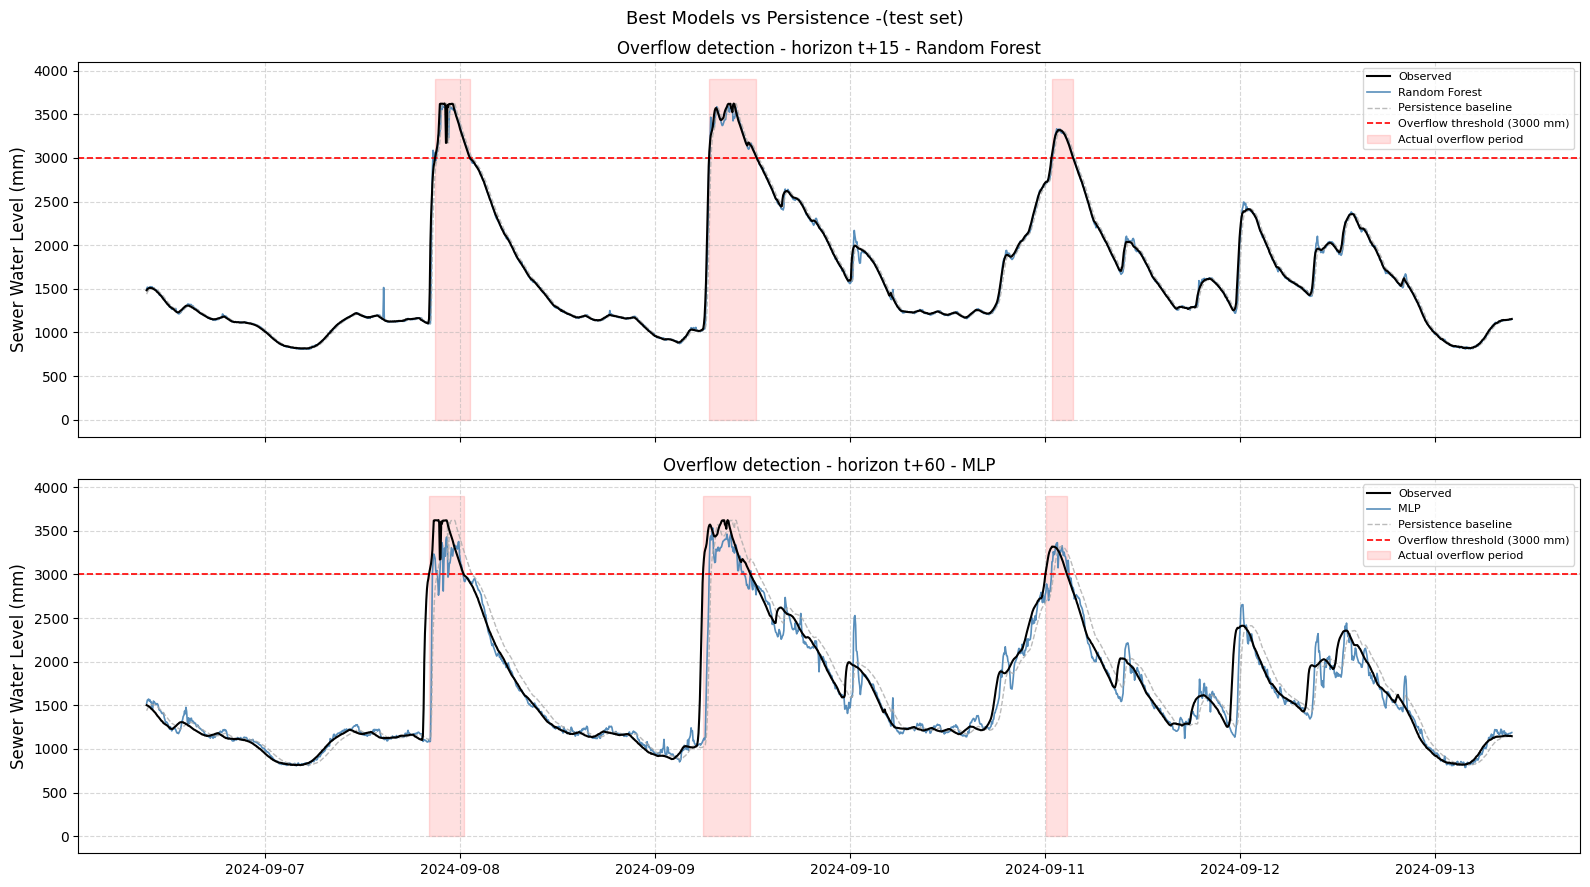

In [60]:
overflow_idx = y_test_15[y_test_15 > OVERFLOW_THRESHOLD].index

if len(overflow_idx) > 0:
    center       = overflow_idx[len(overflow_idx) // 2]
    window_start = center - pd.Timedelta(days=3)
    window_end   = center + pd.Timedelta(days=4)
    mask         = (df_test.index >= window_start) & (df_test.index <= window_end)
    window       = df_test[mask]
    X_window     = window[feature_cols]

    y_obs_15  = window['target_t15'].values
    y_obs_60  = window['target_t60'].values
    y_rf_w_15 = random_rf_15.predict(X_window)
    y_mlp_w_60 = mlp_60.predict(X_window)
    y_base_w  = window['level_mm'].values

    fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

    for ax, y_obs, y_rf, title in [
        (axes[0], y_obs_15, y_rf_w_15, 't+15 - Random Forest'),
        (axes[1], y_obs_60, y_mlp_w_60, 't+60 - MLP')
    ]:
        ax.plot(window.index, y_obs,    color='black',     linewidth=1.5,
                label='Observed', zorder=5)
        ax.plot(window.index, y_rf,     color='steelblue', linewidth=1.2,
                alpha=0.9, label=f'{title.split("-")[1].strip()} ')
        ax.plot(window.index, y_base_w, color='#aaaaaa',   linewidth=1,
                linestyle='--', alpha=0.8, label='Persistence baseline')
        ax.axhline(OVERFLOW_THRESHOLD, color='red', linestyle='--',
                   linewidth=1.2, label='Overflow threshold (3000 mm)')
        ax.fill_between(window.index, 0, OVERFLOW_THRESHOLD * 1.3,
                        where=(y_obs > OVERFLOW_THRESHOLD),
                        alpha=0.12, color='red', label='Actual overflow period')
        ax.set_ylabel('Sewer Water Level (mm)', fontsize=12)
        ax.set_title(f'Overflow detection - horizon {title}', fontsize=12)
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.5)

    plt.suptitle('Best Models vs Persistence -(test set)',
                 fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('No overflow events found in the test set. Check OVERFLOW_THRESHOLD.')

### VIII.7 Discussion

**t+15 vs t+60 overflow detection**

- At t+15, the Random Forest achieves strong performance with a Recall of 96.2% and Precision of 96.9% (F1 = 0.966, AUC = 0.999). The high autocorrelation of the sewer level signal at short lags makes this horizon relatively predictable,

- At t+60, the MLP is the best-performing model with a Recall of 78.6% and Precision of 91.2% (F1 = 0.844, AUC = 0.982). The drop in Recall compared to t+15 (96.2% → 78.6%) reflects the increased uncertainty over a 60-minute window.

**Comparison to the persistence baseline**

- At t+15, the baseline already performs reasonably (Recall = 94.0%, AUC = 0.998) because the level changes little in 15 minutes under most conditions. The Random Forest improves meaningfully on top of this, reducing False Negatives from 96 to 61 and False Positives from 96 to 48.

- At t+60, the baseline degrades significantly (Recall = 77.9%, F1 = 0.780) because the steady-state assumption breaks down over longer horizons, especially during rainfall events where the level rises sharply.


**Class imbalance**

- Overflow events represent approximately 2.6% of all timesteps in the test set (1604 overflow rows out of ~62 675 total). In this context, a model predicting "never overflow" would achieve over 97% accuracy while being operationally useless (F1 = 0 and Recall = 0). The F1-score and AUC are therefore the meaningful metrics here, and both confirm that the selected models provide genuine predictive value over the baseline.